In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm


              Form  Average_Satisfaction  Std_Dev_Satisfaction  Count_of_Drugs
0          Capsule                  3.03                  0.83              73
1            Cream                  3.43                  1.12              90
2   Liquid (Drink)                  3.43                  1.21             119
3  Liquid (Inject)                  2.96                  1.22              57
4            Other                  3.20                  1.41              46
5           Tablet                  3.12                  0.82             300


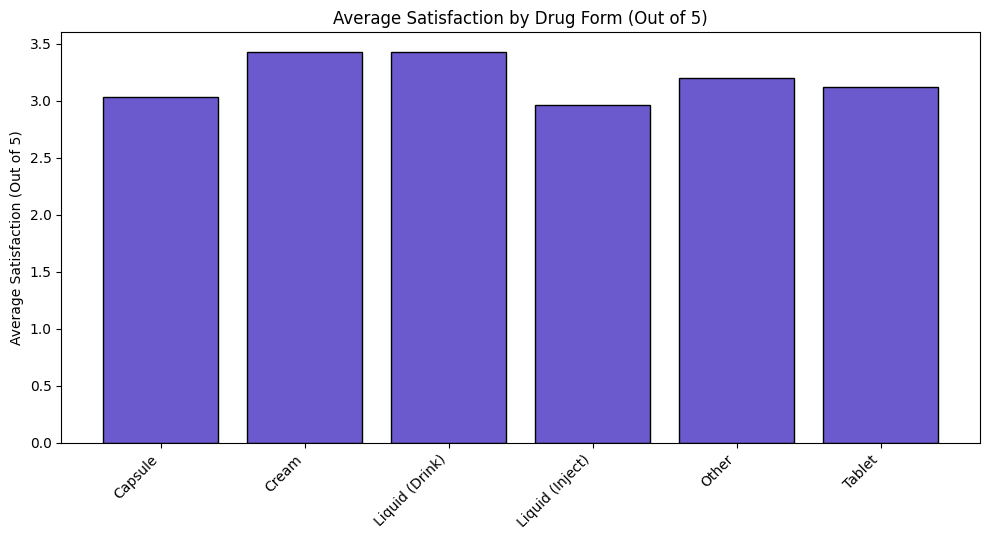

In [40]:
data = pd.read_csv('Drug_clean.csv')

# Ensure Satisfaction is numeric
data['Satisfaction'] = pd.to_numeric(data['Satisfaction'], errors='coerce')

# Drop rows with missing values in Form or Satisfaction
plot_data = data.dropna(subset=['Form', 'Satisfaction'])

# Create summary table: average satisfaction by Form
summary_table = plot_data.groupby('Form').agg(
    Average_Satisfaction=('Satisfaction', 'mean'),
    Std_Dev_Satisfaction=('Satisfaction', 'std'),
    Count_of_Drugs=('Satisfaction', 'count')
).reset_index()

# Round numbers for clarity
summary_table = summary_table.round({'Average_Satisfaction': 2, 'Std_Dev_Satisfaction': 2})

# Display the summary table
print(summary_table)

# Plot bar chart
plt.figure(figsize=(10,5.5))
plt.bar(summary_table['Form'], summary_table['Average_Satisfaction'], color ="slateblue", edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Satisfaction (Out of 5)')
plt.title('Average Satisfaction by Drug Form (Out of 5)')
plt.tight_layout()
plt.show()

/var/folders/cf/325vv1td7yqf_gbjwrjrvgx80000gn/T/ipykernel_8710/1789398999.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_form.index, y=avg_price_form.values, palette='viridis')


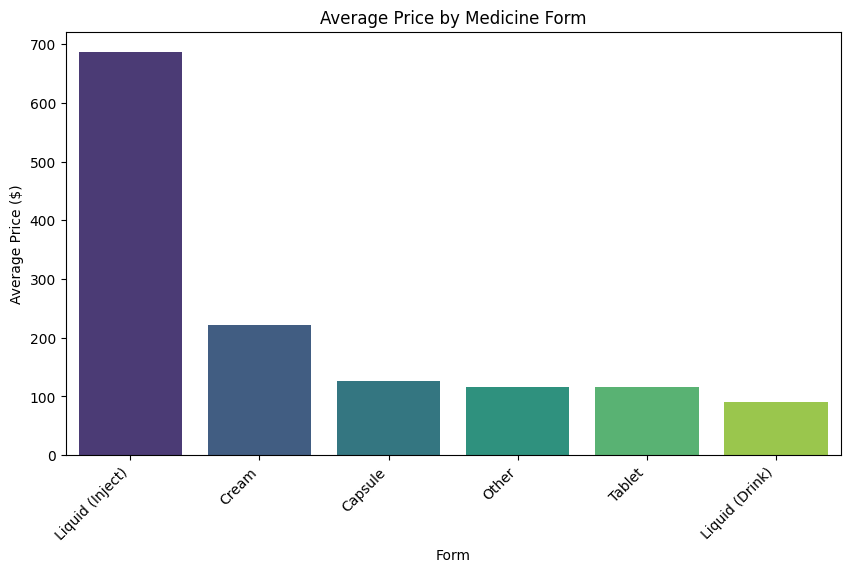

In [24]:
data = pd.read_csv('Drug_clean.csv')

# Ensure Price is numeric
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

# Drop rows with missing values for Price or Form
plot_data = data.dropna(subset=['Price', 'Form'])

# Create bar chart of average Price by Form
avg_price_form = plot_data.groupby('Form')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5.5))
sns.barplot(x=avg_price_form.index, y=avg_price_form.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title("Average Price by Medicine Form")
plt.xlabel("Form")
plt.ylabel("Average Price ($)")
plt.show()

/var/folders/cf/325vv1td7yqf_gbjwrjrvgx80000gn/T/ipykernel_8710/461082490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")


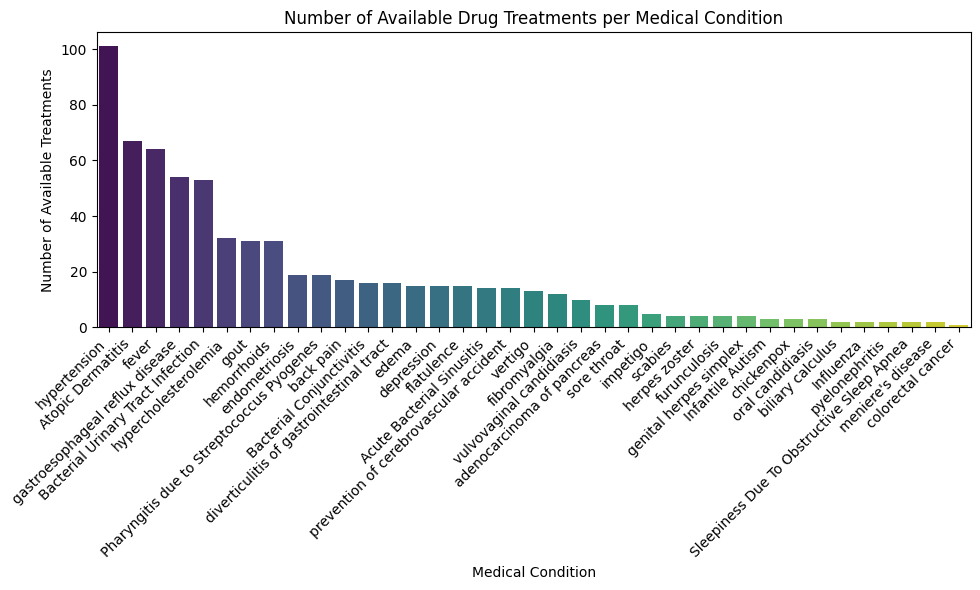

In [30]:
data = pd.read_csv('Drug_clean.csv')

# Count of drugs per condition
condition_counts = data['Condition'].value_counts()

# Create bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=condition_counts.index, y=condition_counts.values, palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Number of Available Drug Treatments per Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Number of Available Treatments")
plt.tight_layout()
plt.show()

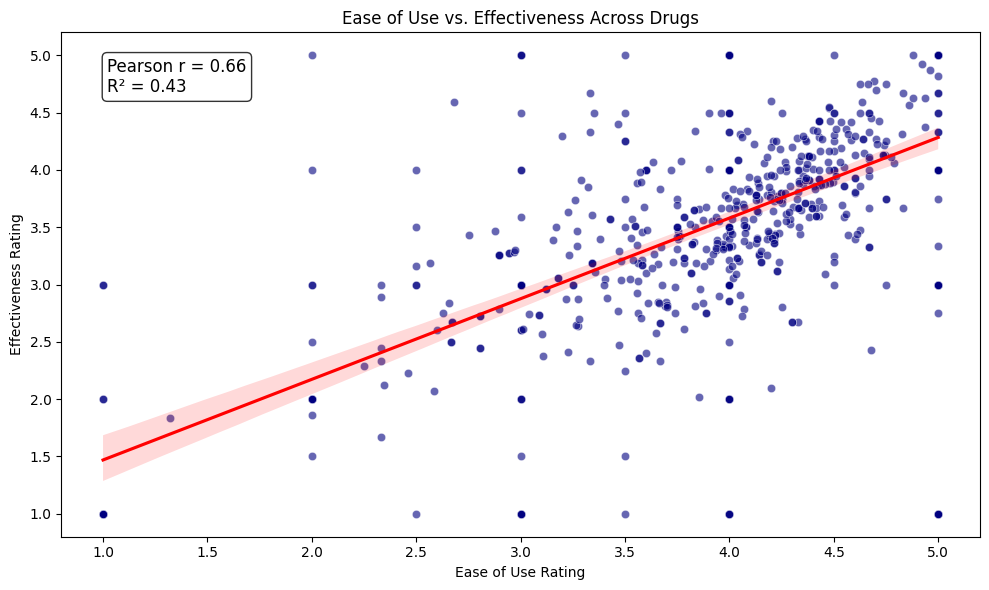

In [45]:
data = pd.read_csv('Drug_clean.csv')
data['Effective'] = pd.to_numeric(data['Effective'], errors='coerce')
data['EaseOfUse'] = pd.to_numeric(data['EaseOfUse'], errors='coerce')
plot_data = data.dropna(subset=['Effective', 'EaseOfUse'])

corr, p_value = stats.pearsonr(plot_data['EaseOfUse'], plot_data['Effective'])
X = sm.add_constant(plot_data['EaseOfUse'])
y = plot_data['Effective']
model = sm.OLS(y, X).fit()
r_squared = model.rsquared

plt.figure(figsize=(10,6))
sns.scatterplot(x='EaseOfUse', y='Effective', data=plot_data, alpha=0.6, color='navy')
sns.regplot(x='EaseOfUse', y='Effective', data=plot_data, scatter=False, color='red')

# Add a text box with Pearson correlation and R²
plt.text(
    0.05, 0.95,
    f"Pearson r = {corr:.2f}\nR² = {r_squared:.2f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.title("Ease of Use vs. Effectiveness Across Drugs")
plt.xlabel("Ease of Use Rating")
plt.ylabel("Effectiveness Rating")
plt.tight_layout()
plt.show()

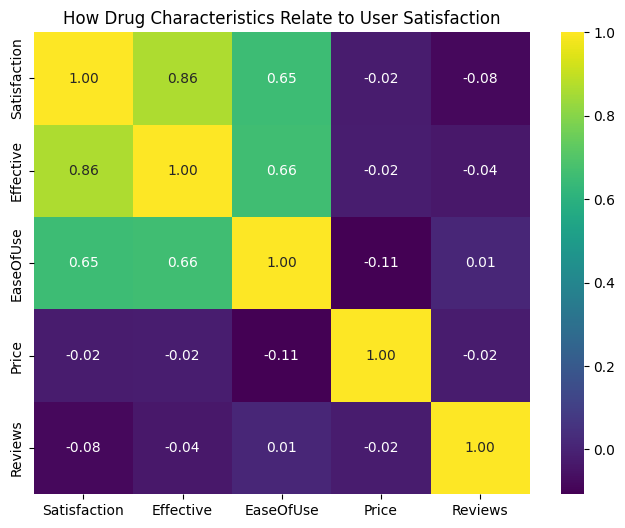

In [43]:
data = pd.read_csv('Drug_clean.csv')

numeric_cols = ['Satisfaction', 'Effective', 'EaseOfUse', 'Price', 'Reviews']

# Ensure all numeric columns are numeric
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with missing values in numeric columns
plot_data = data.dropna(subset=numeric_cols)

# Compute correlation matrix
corr_matrix = plot_data[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("How Drug Characteristics Relate to User Satisfaction")
plt.show()